In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../../tmp_data/merged_part_2.csv")
pd.set_option('display.max_columns', None)

In [102]:
df = df.drop(columns = [
        "ceiling_height",
        "metro_minutes",
        "metro_walking",
        "total_area",
        "living_area",
        "kitchen_area",
        "price",
        "utilities_amount",
        "utilities_included",
        "prepayment_months",
        "is_long_rental_term",
    ]
)

In [103]:
def check_isolated_room(types_room, rooms_count):
    rooms_count_num = float(rooms_count) if rooms_count not in [None, 'nan', ''] else np.nan
    
    if pd.isna(types_room):
        return 0 if (rooms_count_num == 1) else None
    if rooms_count_num == 2 and pd.notna(types_room) and 'Оба варианта' in str(types_room):
        return 0
    if pd.notna(types_room) and ('Изолированная' in str(types_room) or 'Оба варианта' in str(types_room)):
        return 1
    return 0

def check_adjacent_room(types_room, rooms_count):
    rooms_count_num = float(rooms_count) if rooms_count not in [None, 'nan', ''] else np.nan
    
    if pd.isna(types_room):
        return 0 if rooms_count_num == 1 else None
    if rooms_count_num == 1:
        return 0
    if rooms_count_num == 2 and pd.notna(types_room) and 'Оба варианта' in str(types_room):
        return 1
    if pd.notna(types_room) and ('Смежная' in str(types_room) or 'Оба варианта' in str(types_room)):
        return 1
    return 0

df['is_isolated'] = df.apply(lambda row: check_isolated_room(row['types_room'], row['rooms_count']), axis=1)
df['is_adjacent'] = df.apply(lambda row: check_adjacent_room(row['types_room'], row['rooms_count']), axis=1)

mode_by_rooms = df[df['types_room'].notna()].groupby('rooms_count')['is_isolated'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

def fill_with_mode(row):
    if pd.isna(row['is_isolated']) and pd.notna(row['rooms_count']):
        return mode_by_rooms.get(row['rooms_count'], None)
    return row['is_isolated']

df['is_isolated'] = df.apply(fill_with_mode, axis=1)
df['is_adjacent'] = df.apply(fill_with_mode, axis=1)

In [104]:
df['view_of_courtyard'] = df['view_of_courtyard'].fillna(
    (df['floor'] <= 5).astype(int)
)

df['view_of_street'] = df['view_of_street'].fillna(
    (df['floor'] >= 8).astype(int)
)

In [105]:
## Балкон

house_balcony_features = {
    0: {'loggia': 0, 'balcony': 1},
    1: {'loggia': 0, 'balcony': 1},
    2: {'loggia': 0, 'balcony': 1},
    3: {'loggia': 0, 'balcony': 1},
    4: {'loggia': 0, 'balcony': 1},
    5: {'loggia': 0, 'balcony': 1},
    6: {'loggia': 0, 'balcony': 2},
    7: {'loggia': 0, 'balcony': 1},
    8: {'loggia': 1, 'balcony': 1},
    9: {'loggia': 2, 'balcony': 0}
}

df['count_loggia'] = df.apply(lambda row: 
    row['count_loggia'] if pd.notna(row['count_loggia']) else (
        house_balcony_features.get(row['house_type'], {'loggia': 0})['loggia']
        if pd.notna(row['house_type']) else 0
    ), axis=1
)

# Заполняем count_balcony
df['count_balcony'] = df.apply(lambda row: 
    row['count_balcony'] if pd.notna(row['count_balcony']) else (
        house_balcony_features.get(row['house_type'], {'balcony': 1})['balcony']
        if pd.notna(row['house_type']) else 1
    ), axis=1
)

In [106]:
df = df.drop(columns=["types_room"])

In [107]:
df['house_type_known'] = df['house_type'].notna().astype(int)

mode_by_floor = df.groupby('house_floor')['house_type'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)

mask = df['house_type'].isna()
df.loc[mask, 'house_type'] = df.loc[mask, 'house_floor'].map(mode_by_floor)


df['house_type'] = df['house_type'].fillna(df['house_type'].mode()[0])

In [108]:
## Мусоропровод

def fill_garbage_chute(row):
    house_type = row['house_type']
    house_floor = row['house_floor']
    has_lift = row['count_passenger_lift'] > 0 or row['count_freight_lift'] > 0
    
    if pd.isna(house_type):
        return np.nan
    
    house_type = int(house_type)  # конвертируем float в int

    if house_type in [0, 1]:  # Панельный, Блочный
        return 1 if house_floor >= 9 else 0
    
    elif house_type in [2, 3]:  # Щитовой, Деревянный
        return 0

    elif house_type == 4:  # Газобетонный
        return 1 if (house_floor >= 12 and has_lift) else 0
    
    elif house_type == 5:  # Кирпичный
        return 1 if house_floor >= 5 else 0
    
    elif house_type == 6:  # Сталинский
        return 1 if house_floor > 10 else 0
    
    elif house_type == 7:  # Старый фонд
        return 0
    
    elif house_type == 8:  # Монолитно-кирпичный
        return 1 if (house_floor >= 17 and has_lift) else 0
    
    # Монолитные
    elif house_type == 9:  # Монолитный
        return 0
    
    else:
        return np.nan

# Применяем функцию
df['is_garbage_chute'] = df.apply(fill_garbage_chute, axis=1)

In [109]:
def fill_parking_logic(row):
    if pd.isna(row['parking']) and pd.notna(row['house_type']):
        house_type = row['house_type']
        
        # Современные дома (монолит, монолитно-кирпичный) - чаще подземный паркинг
        if house_type in [8, 9]:  # Монолитно-кирпичный, Монолитный
            return 4  # Подземная
            
        # Кирпичные, сталинские дома - могут быть разные варианты
        elif house_type in [5, 6]:  # Кирпичный, Сталинский
            return np.random.choice([0, 1, 4], p=[0.3, 0.3, 0.4])
            
        # Панельные, блочные, щитовые - чаще наземная или открытая
        elif house_type in [0, 1, 2]:  # Панельный, Блочный, Щитовой
            return np.random.choice([0, 1], p=[0.6, 0.4])
            
        # Старый фонд, деревянные - обычно наземная парковка
        elif house_type in [3, 7]:  # Деревянный, Старый фонд
            return 0  # Наземная
            
        # Газобетонные - современные, могут быть разные
        elif house_type == 4:  # Газобетонный
            return np.random.choice([0, 1, 4], p=[0.4, 0.3, 0.3])
    
    return row['parking']

df['parking'] = df.apply(fill_parking_logic, axis=1)

In [120]:
df['renovation_known'] = df['renovation'].notna().astype(int)

mode_by_house = df.groupby('house_type')['renovation'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)

mask = df['renovation'].isna()
df.loc[mask, 'renovation'] = df.loc[mask, 'house_type'].map(mode_by_house)

df['renovation'] = df['renovation'].fillna(df['renovation'].mode()[0])

In [123]:
df.to_csv('../../realises/seaborn_team_data.csv', index=False)

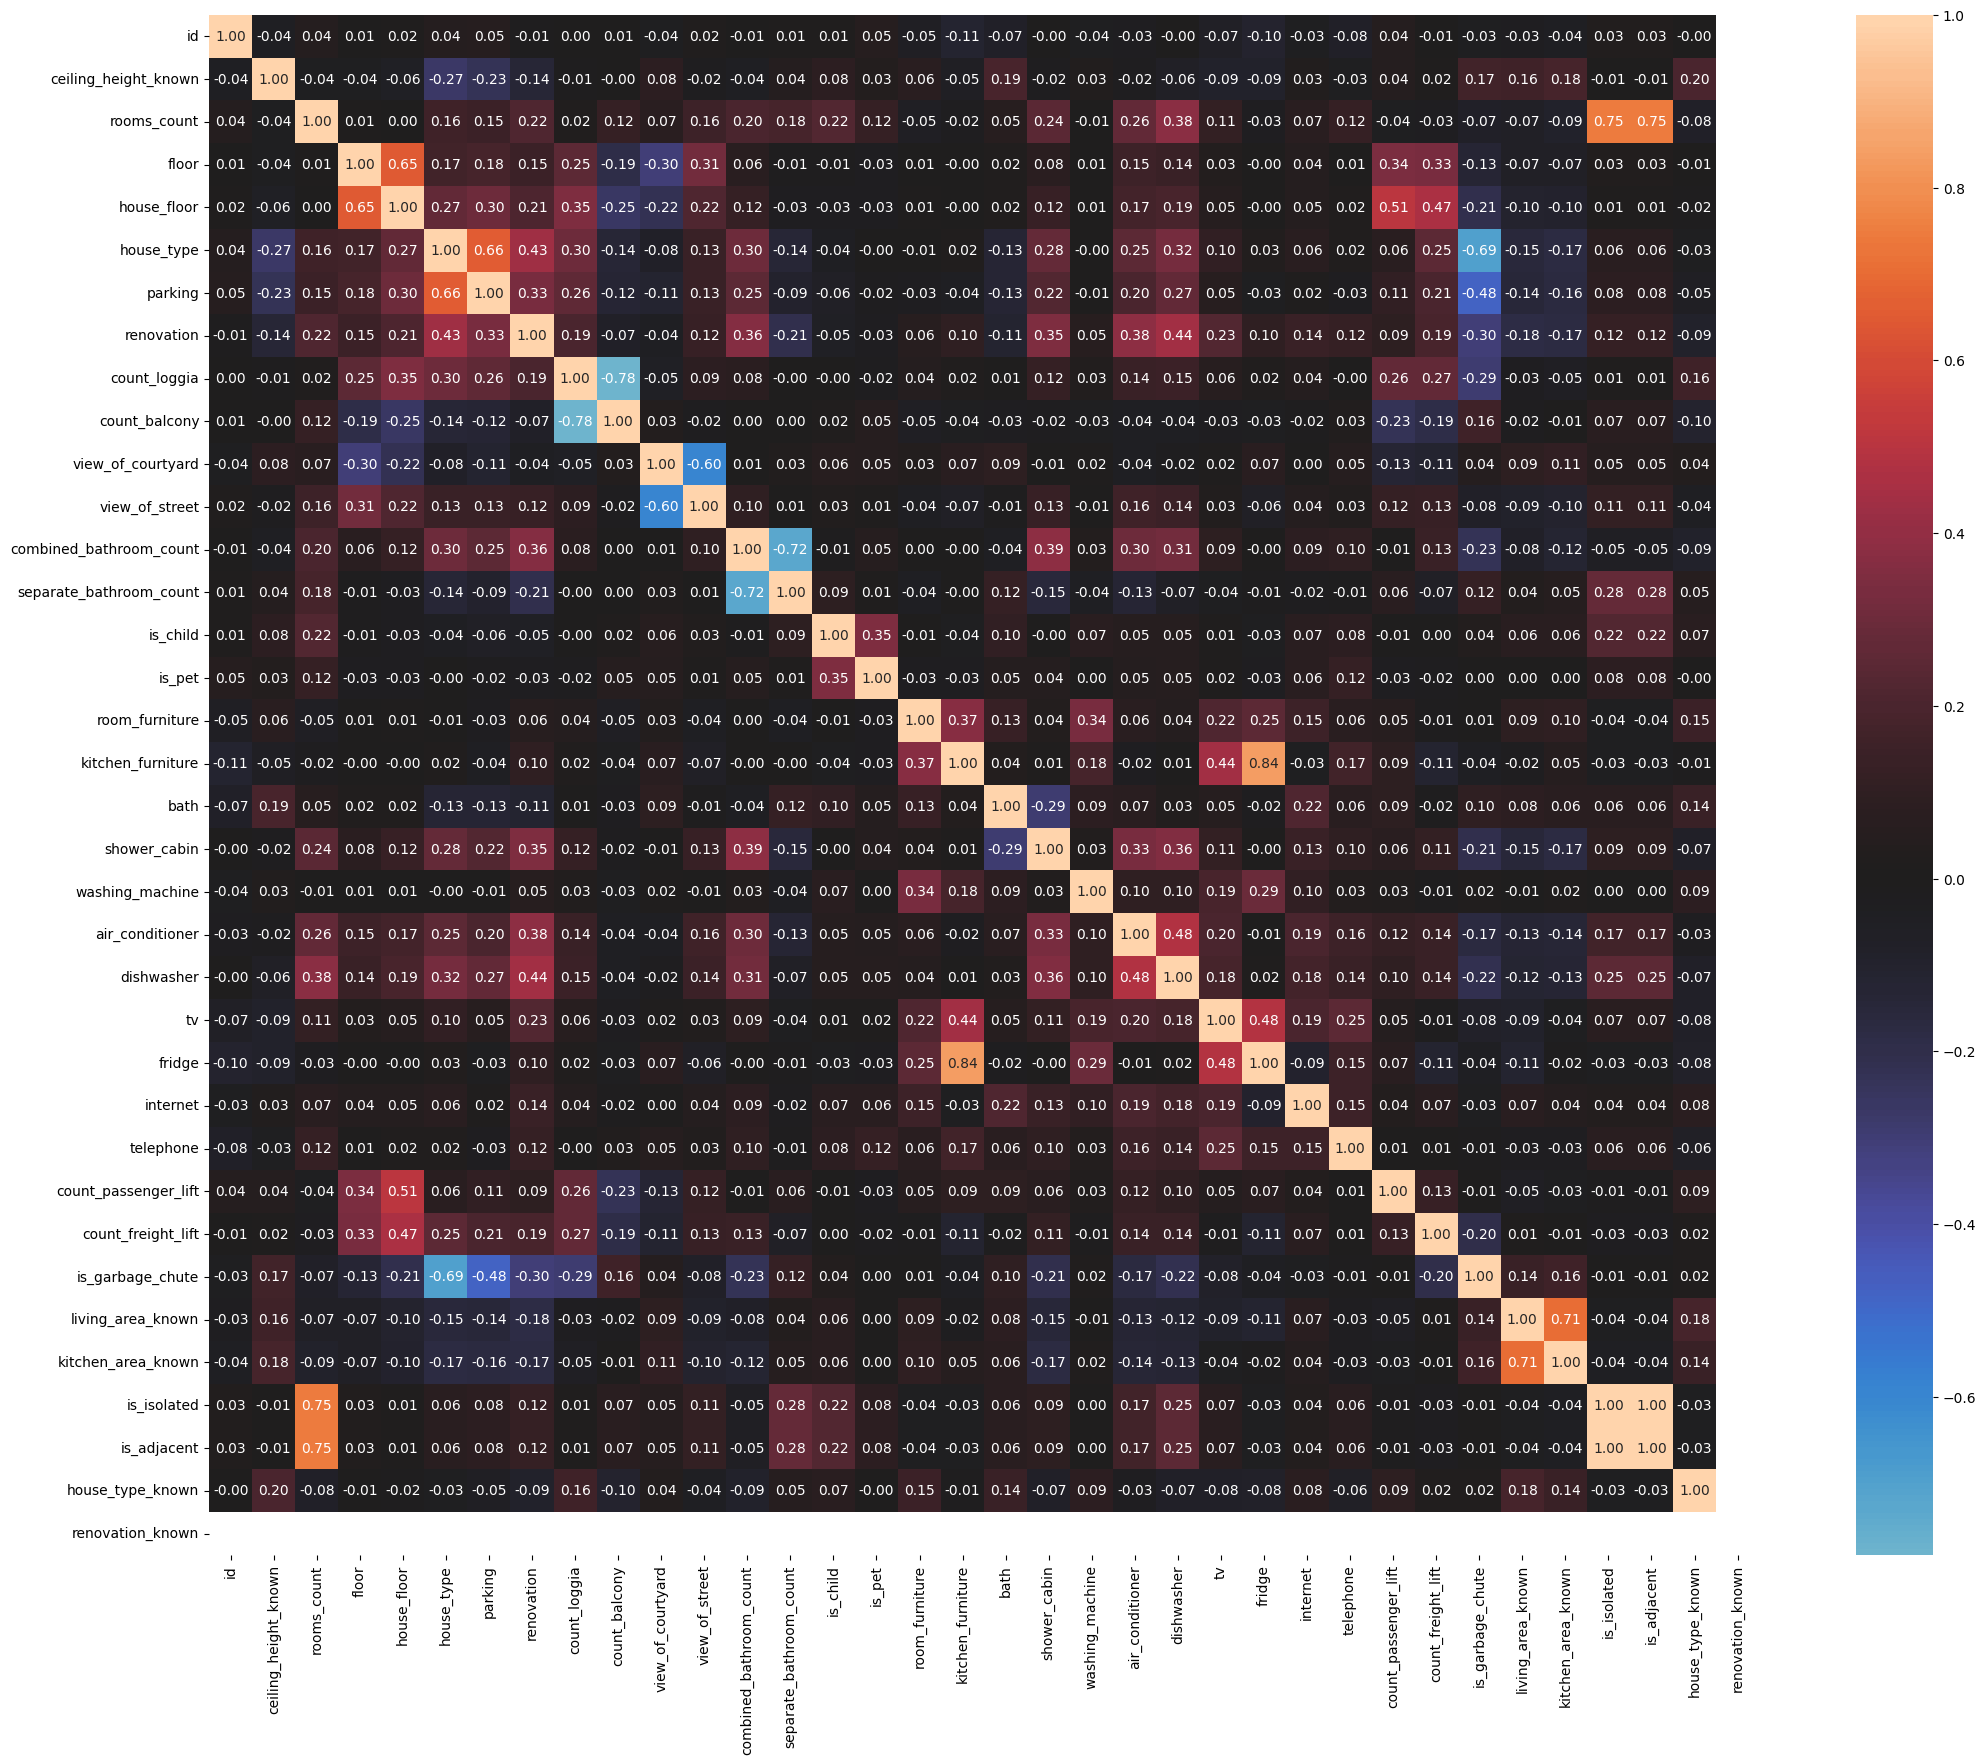

In [124]:
plt.figure(figsize=(25, 20))
sns.heatmap(df.corr(numeric_only = True), annot = True, center = 0, fmt = ".2f");